In [ ]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

# Trabalho 3 — Marcas d’Água em Dados para Auditoria de Modelos Generativos

> **Pergunta central:** como podemos marcar um conjunto de dados de forma que, se ele for usado no treinamento de um modelo generativo, seja possível auditar posteriormente esse uso?

Neste trabalho usaremos **Variational Autoencoder** como nosso método generativo base, e investigaremos estratégias para **auditoria de uso de dados em modelos generativos**. A situação é a seguinte: o dono de uma base de dados disponibiliza um conjunto de imagens, mas quer preservar a capacidade de verificar, posteriormente, se essas imagens foram usadas por terceiros no treinamento de um modelo generativo.

Para isso, vamos estudar a ideia de inserir uma **marca d’água nos dados de treino**.
Vamos fazer esse estudo usando os dados do MNIST.

Exploraremos duas estratégias:
1. **Marca visível** — patch fixo no canto da imagem. Fácil de detectar, trivialmente removível.
2. **Marca spread-spectrum** — textura pseudo-aleatória de baixa amplitude. Idealmente imperceptível ao olho, detectável via correlação com a chave secreta.

E faremos um **estudo de ablação** variando amplitude, fração marcada e o número de amostras usadas para a auditoria.

**Entregáveis.**
1. Notebook preenchido e executado.
2. Pesos dos VAEs treinados (limpo, marca visível, marca spread-spectrum).
3. Respostas das questões com evidências numéricas dos seus próprios resultados.

**Regras.** Use PyTorch. Fixe seeds. Não apague células do enunciado.

## Parte 0 — Setup e reprodutibilidade

**Tarefa 0.1.** Fixe as seeds aleatórias e configure o dispositivo.

**Tarefa 0.2.** Imprima as versões de `torch` e `torchvision`.

**Tarefa 0.3.** Defina `student_run_tag` (suas iniciais + data) — use ao salvar artefatos.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

SEED       = 42    # semente do experimentador: splits, pesos, etc.
OWNER_SEED = 1234  # semente do dono dos dados: gera o padrão secreto


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

student_run_tag = "DCP_06_02"   # ex: "DA_2026-05-22"
output_dir = Path("trabalho3_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {output_dir}")

Dispositivo: cuda
Torch: 2.5.1+cu121  |  Torchvision: 0.20.1+cu121
Output dir: trabalho3_outputs/DCP_06_02


## Parte 1 — VAE no MNIST

Antes de pensar em marca d'água, precisamos de um modelo generativo razoável. Vamos construir um VAE simples no MNIST.

### 1.1 Dados

**Tarefa 1.1.** Carregue o MNIST de treino e teste com `torchvision.datasets.MNIST` (transformação: apenas `ToTensor()`).

In [5]:
transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(
    root='./data', 
    train=True, 
    transform=transform, 
    download=True
)

test_ds = datasets.MNIST(
    root='./data', 
    train=False, 
    transform=transform, 
    download=True
)

BATCH_SIZE = 256

train_loader = DataLoader(
    dataset=train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

print(f"Treino: {len(train_ds):,}  |  Teste: {len(test_ds):,}")

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Treino: 60,000  |  Teste: 10,000


### 1.2 Arquitetura do VAE

Um VAE é composto por:
- **Encoder** $q_\phi(z \mid x)$: projeta a imagem no espaço latente, produzindo $\mu$ e $\log\sigma^2$.
- **Reparametrização**: $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0, I)$.
- **Decoder** $p_\theta(x \mid z)$: reconstrói a imagem a partir de $z$ (saída em $[0,1]$ via sigmoid).

**Tarefa 1.2.** Implemente `Encoder`, `Decoder`, `VAE`. Use uma MLP simples (camadas escondidas de 512 e 256 unidades com ReLU). A dimensão latente (`LATENT_DIM`) é um hiperparâmetro configurável — para MNIST, valores entre 2 e 32 produzem modelos razoáveis.

In [6]:
LATENT_DIM = 12
IMG_DIM = 28 * 28

class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_DIM, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        h = self.net(x_flat)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var


class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, IMG_DIM),
            nn.Sigmoid() 
        )

    def forward(self, z):
        out = self.net(z)
        return out.view(-1, 1, 28, 28)


class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparametrize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparametrize(mu, log_var)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

model = VAE(LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LATENT_DIM = {LATENT_DIM}  |  Parâmetros: {n_params:,}")

LATENT_DIM = 12  |  Parâmetros: 1,076,520


### 1.3 Função de perda — ELBO

O VAE maximiza o **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x \mid z)]}_{\text{reconstrução}} - \underbrace{D_{KL}(q_\phi(z|x) \,\|\, p(z))}_{\text{regularização}}$$

Para imagens com pixels em $[0,1]$, usamos **BCE** (Bernoulli) como modelo de reconstrução. Como prior, $p(z) = \mathcal{N}(0, I)$, e a KL tem forma fechada:

$$D_{KL}(q_\phi(z|x) \| \mathcal{N}(0,I)) = -\frac{1}{2}\sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

**Tarefa 1.3.** Implemente `vae_loss` que retorna `(loss_total, recon, kl)`. Use BCE com `reduction="sum"` (some sobre pixels e batch).

In [7]:
def vae_loss(x, x_hat, mu, log_var):
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - torch.exp(log_var))
    loss_total = recon + kl
    
    return loss_total, recon, kl

### 1.4 Treinamento

Treine por **30 épocas** com Adam (lr=1e-3). A loss é a ELBO (somada sobre o batch, dividida no final por `len(dataset)` para reportar por amostra).

**Tarefa 1.4.** Implemente o loop de treino e salve o histórico de loss/recon/KL para treino e teste.

In [8]:
from pathlib import Path

EPOCHS = 30
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {"train_loss": [], "train_recon": [], "train_kl": [],
           "test_loss":  [], "test_recon":  [], "test_kl":  []}

def run_epoch(loader, train: bool):
    if train:
        model.train()
        torch.set_grad_enabled(True)
    else:
        model.eval()
        torch.set_grad_enabled(False)

    epoch_loss = 0.0
    epoch_recon = 0.0
    epoch_kl = 0.0

    for x, _ in loader:
        x = x.to(device)

        if train:
            optimizer.zero_grad()

        x_hat, mu, log_var = model(x)
        
        loss_total, recon, kl = vae_loss(x, x_hat, mu, log_var)

        if train:
            loss_total.backward()
            optimizer.step()

        epoch_loss += loss_total.item()
        epoch_recon += recon.item()
        epoch_kl += kl.item()

    num_samples = len(loader.dataset)
    
    mean_loss = epoch_loss / num_samples
    mean_recon = epoch_recon / num_samples
    mean_kl = epoch_kl / num_samples

    return mean_loss, mean_recon, mean_kl


for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    te = run_epoch(test_loader,  train=False)
    
    for key, value in zip(["loss", "recon", "kl"], tr):
        history[f"train_{key}"].append(value)
    for key, value in zip(["loss", "recon", "kl"], te):
        history[f"test_{key}"].append(value)
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Ep {epoch:3d}/{EPOCHS} | tr loss {tr[0]:.2f}  recon {tr[1]:.2f}  kl {tr[2]:.2f} | te loss {te[0]:.2f}")

torch.save(model.state_dict(), output_dir / f"vae_clean_latent{LATENT_DIM}.pt")
print("Salvo.")

Ep   1/30 | tr loss 200.44  recon 196.34  kl 4.11 | te loss 163.47
Ep   5/30 | tr loss 114.24  recon 97.25  kl 16.99 | te loss 111.69
Ep  10/30 | tr loss 106.11  recon 87.46  kl 18.65 | te loss 105.58
Ep  15/30 | tr loss 103.18  recon 84.07  kl 19.11 | te loss 103.41
Ep  20/30 | tr loss 101.57  recon 82.18  kl 19.39 | te loss 102.03
Ep  25/30 | tr loss 100.33  recon 80.79  kl 19.54 | te loss 101.15
Ep  30/30 | tr loss 99.52  recon 79.84  kl 19.68 | te loss 100.75
Salvo.


### 1.5 Visualizações

Produza as seguintes visualizações (use o conjunto de teste para a maioria, com seeds fixas).

**Tarefa 1.5a.** Plote as **curvas de treino** (loss total, recon, KL) para treino e teste.

**Tarefa 1.5b.** Mostre **10 reconstruções** lado a lado com os originais.

**Tarefa 1.5c.** Projete o conjunto de teste no espaço latente (use $\mu$, não amostra) e plote um scatter colorido por dígito. *Se `LATENT_DIM > 2`, faça uma redução de dimensionalidade para 2D antes de plotar — use PCA via `numpy.linalg.svd` (centralize os dados antes do SVD; não use sklearn).*

**Tarefa 1.5d.** Amostre 20 imagens do prior ($z \sim \mathcal{N}(0, I)$) e mostre o que o decoder gera.

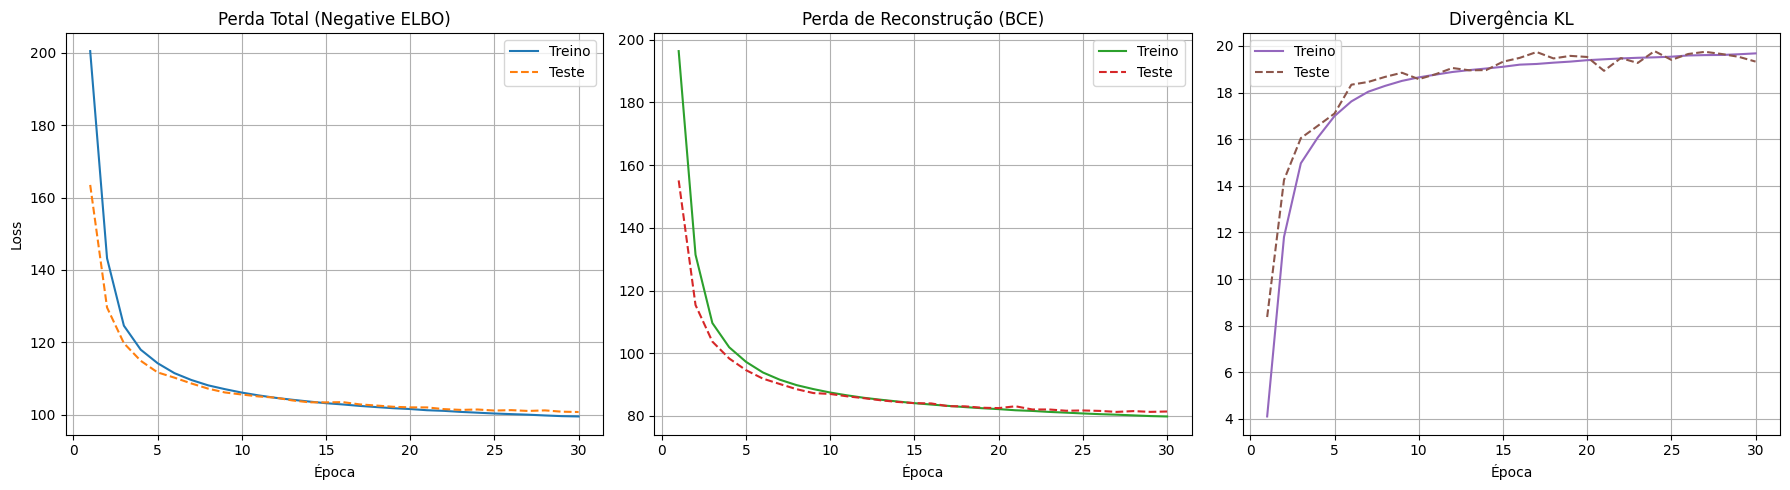

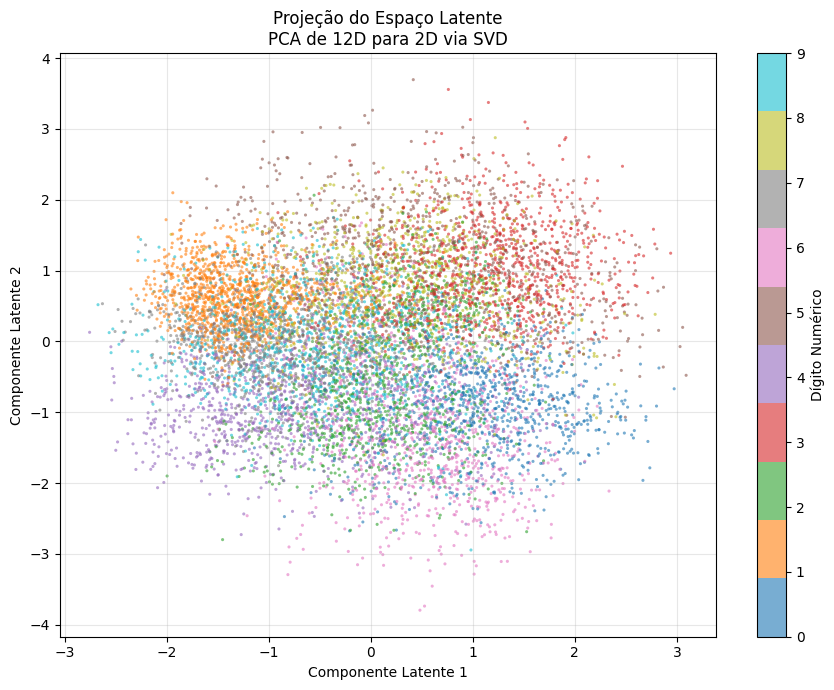

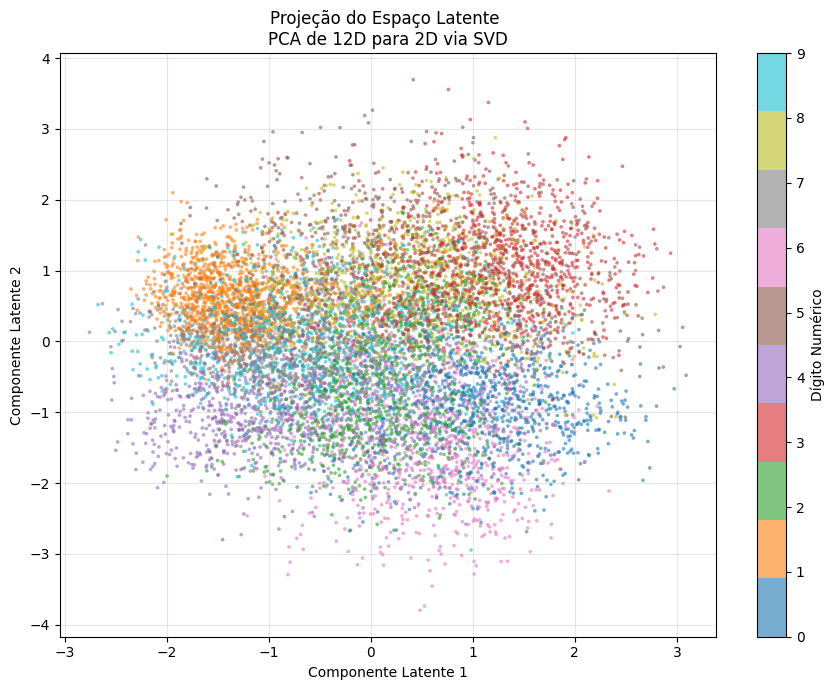

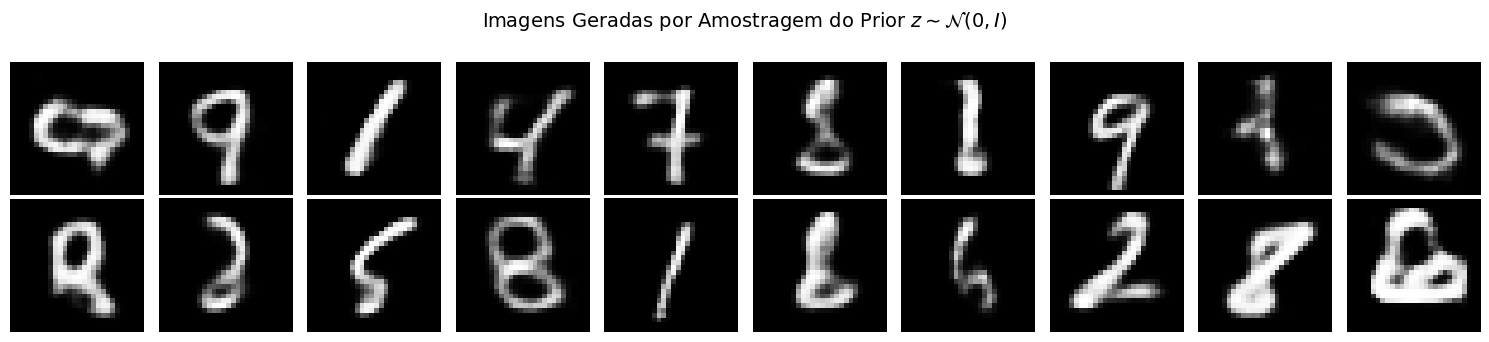

In [12]:
# TODO: implementar as 4 visualizações 1.5a–1.5d
# - curvas de treinamento (3 subplots)
# - reconstruções (2x10)
# - espaço latente em 2D (scatter colorido por dígito; PCA se LATENT_DIM > 2)
# - amostras do prior (2x10)
# Salve as figuras em output_dir.

mus_all = []
ys_all = []

model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        mu_batch, _ = model.encoder(x_batch)  
        
        mus_all.append(mu_batch.cpu().numpy())
        ys_all.append(y_batch.numpy())

mu_test = np.concatenate(mus_all, axis=0)
y_test = np.concatenate(ys_all, axis=0)

# Tarefa 1.5a

epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(epochs_range, history["train_loss"], label="Treino", color="tab:blue")
axs[0].plot(epochs_range, history["test_loss"], label="Teste", color="tab:orange", linestyle="--")
axs[0].set_title("Perda Total (Negative ELBO)")
axs[0].set_xlabel("Época")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)


axs[1].plot(epochs_range, history["train_recon"], label="Treino", color="tab:green")
axs[1].plot(epochs_range, history["test_recon"], label="Teste", color="tab:red", linestyle="--")
axs[1].set_title("Perda de Reconstrução (BCE)")
axs[1].set_xlabel("Época")
axs[1].legend()
axs[1].grid(True)


axs[2].plot(epochs_range, history["train_kl"], label="Treino", color="tab:purple")
axs[2].plot(epochs_range, history["test_kl"], label="Teste", color="tab:brown", linestyle="--")
axs[2].set_title("Divergência KL")
axs[2].set_xlabel("Época")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show() 



# Tarefa 1.5b

plt.figure(figsize=(9, 7))

if LATENT_DIM == 2:
    z_2d = mu_test
    title_suffix = "Direto (LATENT_DIM=2)"
else:
    mu_centered = mu_test - np.mean(mu_test, axis=0)
    _, _, Vt = np.linalg.svd(mu_centered, full_matrices=False)
    z_2d = np.dot(mu_centered, Vt[:2].T)
    title_suffix = f"PCA de {LATENT_DIM}D para 2D via SVD"

scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_test, cmap="tab10", alpha=0.6, edgecolors='none', s=5)
plt.colorbar(scatter, label="Dígito Numérico")
plt.title(f"Projeção do Espaço Latente\n{title_suffix}")
plt.xlabel("Componente Latente 1" if LATENT_DIM > 2 else "Dimensão Latente 1")
plt.ylabel("Componente Latente 2" if LATENT_DIM > 2 else "Dimensão Latente 2")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Tarefa 1.5c

plt.figure(figsize=(9, 7))

if LATENT_DIM == 2:
    z_2d = mu_test
    title_suffix = "Direto (LATENT_DIM=2)"
else:
    mu_centered = mu_test - np.mean(mu_test, axis=0)
    _, _, Vt = np.linalg.svd(mu_centered, full_matrices=False)
    z_2d = np.dot(mu_centered, Vt[:2].T)
    title_suffix = f"PCA de {LATENT_DIM}D para 2D via SVD"

# Plot do Scatter
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_test, cmap="tab10", alpha=0.6, edgecolors='none', s=7)
plt.colorbar(scatter, label="Dígito Numérico")
plt.title(f"Projeção do Espaço Latente \n{title_suffix}")
plt.xlabel("Componente Latente 1" if LATENT_DIM > 2 else "Dimensão Latente 1")
plt.ylabel("Componente Latente 2" if LATENT_DIM > 2 else "Dimensão Latente 2")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tarefa 1.5d
with torch.no_grad():
    z_sampled = torch.randn(20, LATENT_DIM).to(device)
    x_generated = model.decoder(z_sampled).cpu().numpy()

fig, axs = plt.subplots(2, 10, figsize=(15, 3.5))
for i in range(20):
    row = i // 10
    col = i % 10
    axs[row, col].imshow(x_generated[i, 0], cmap="gray")
    axs[row, col].axis("off")

plt.suptitle(r"Imagens Geradas por Amostragem do Prior $z \sim \mathcal{N}(0, I)$", fontsize=14)
plt.tight_layout()
plt.show() 

### Questão 1 — Análise do VAE base

**a)** Compare as curvas de treino e teste. O modelo apresenta underfitting, overfitting, ou está bem ajustado? Justifique com o gap treino/teste e a tendência das curvas.

**b)** Compare reconstruções com amostras do prior. Em qual das duas o VAE produz imagens melhores? Por quê?

**c)** Na projeção 2D do espaço latente (direta se `LATENT_DIM=2`, via PCA caso contrário), as classes ficam separadas? Existem regiões vazias? Conecte a estrutura latente à qualidade das amostras geradas.

**Resposta:**

**a)** O modelo está bem ajustado. As curvas de treino e teste caem juntas e estabilizam sem divergir. O gap entre elas é quase nulo e a perda de reconstrução baixa estabiliza, mostrando que a MLP tem capacidade adequada e descarta underfitting. A estabilização da KL mostra equilíbrio entre reconstruir bem e regularizar o espaço.

**b)** As reconstruções são melhores. Elas usam vetores latentes condicionados a imagens reais passadas pelo encoder. As amostras do prior usam pontos puramente aleatórios de $\mathcal{N}(0, I)$, como a regularização KL não é perfeita, alguns pontos caem em zonas de transição do espaço latente, gerando dígitos borrados ou misturados.

**c)** As classes aparecem separadas em clusters, mas com sobreposições nas fronteiras de dígitos parecidos (como 4, 7 e 9). Não há regiões vazias porque a KL força os dados para perto da origem em formato de Gaussiana. Essa estrutura compacta e sem buracos garante que quase qualquer ponto sorteado no centro gere um dígito compreensível.

## Parte 2 — Marca d'água visível (warmup do auditor)

A versão mais simples do problema: o dono dos dados estampa um **patch branco fixo** num canto das imagens. Esta marca é trivialmente visível, mas serve como referência para entendermos o "limite superior" da detectabilidade.



### 2.1 Definir a marca e o dataset

A marca é um quadrado branco $4 \times 4$ no canto inferior direito (posição `[22:26, 22:26]`), valor $1.0$. Marcamos 20% das imagens de treino, selecionadas aleatoriamente com seed fixa.

**Tarefa 2.1.** Implemente:
- A função `apply_visible_watermark(img)`.
- A classe `VisibleWatermarkedMNIST` que envolve `train_ds` e marca aleatoriamente uma fração das imagens, mantendo `watermarked_indices` para análise posterior.

In [17]:
PATCH_ROW, PATCH_COL = 22, 22
PATCH_SIZE = 4
WM_FRACTION = 0.20

def apply_visible_watermark(img: torch.Tensor) -> torch.Tensor:

    img_wm = img.clone()

    img_wm[:, PATCH_ROW:PATCH_ROW+PATCH_SIZE, PATCH_COL:PATCH_COL+PATCH_SIZE] = 1.0
    return img_wm


class VisibleWatermarkedMNIST(Dataset):
    def __init__(self, base_dataset, fraction=WM_FRACTION, seed=SEED):
        self.base_dataset = base_dataset
        self.fraction = fraction
        
        total_samples = len(self.base_dataset)
        num_to_watermark = int(total_samples * self.fraction)
        
        rng = np.random.default_rng(seed)
        chosen_indices = rng.choice(total_samples, size=num_to_watermark, replace=False)
        
        self.watermarked_indices = sorted(chosen_indices.tolist())

        self.watermarked_set = set(self.watermarked_indices)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        
        if idx in self.watermarked_set:
            img = apply_visible_watermark(img)
            
        return img, label


vis_ds = VisibleWatermarkedMNIST(train_ds)
print(f"Marcadas: {len(vis_ds.watermarked_indices):,} / {len(vis_ds):,}")

Marcadas: 12,000 / 60,000


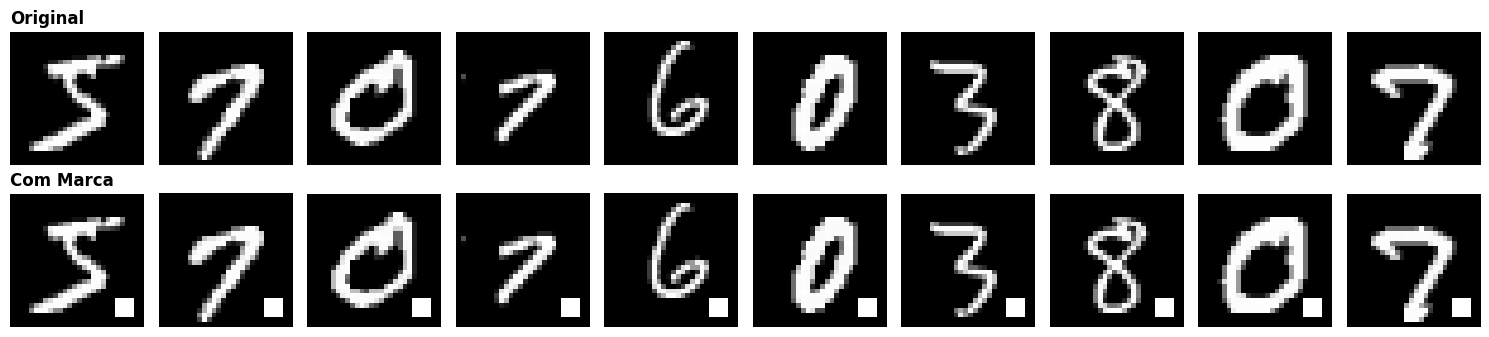

In [18]:
indices_para_mostrar = vis_ds.watermarked_indices[:10]

fig, axs = plt.subplots(2, 10, figsize=(15, 3.5))

for i, idx in enumerate(indices_para_mostrar):
    img_original, _ = vis_ds.base_dataset[idx]
    axs[0, i].imshow(img_original[0], cmap="gray")
    axs[0, i].axis("off")
    if i == 0: 
        axs[0, i].set_title("Original", loc="left", fontweight="bold")
    
    img_marcada, _ = vis_ds[idx]
    axs[1, i].imshow(img_marcada[0], cmap="gray")
    axs[1, i].axis("off")
    if i == 0: 
        axs[1, i].set_title("Com Marca", loc="left", fontweight="bold")

plt.tight_layout()
plt.show()

### 2.2 Treinar o VAE marcado

Treine um novo VAE (`vae_vis`) com **a mesma arquitetura** do `model` (mesma `LATENT_DIM`) mas usando `vis_ds` como dataset de treino. Use 30 épocas, Adam lr=1e-3.

**Dica.** Modularize: escreva uma função `train_vae(loader, latent_dim, epochs, label)` que cria, treina e retorna um novo VAE. Vamos reutilizá-la várias vezes nas próximas partes.

In [21]:
import torch.optim as optim

def train_vae(loader, latent_dim, epochs, label, lr=1e-3):
    """
    Instancia, treina e retorna um modelo VAE usando o loader fornecido.
    """
    model_vae = VAE(latent_dim).to(device)
    optimizer = optim.Adam(model_vae.parameters(), lr=lr)
    
    num_samples = len(loader.dataset)
    print(f"--- Iniciando Treino do VAE [{label}] | Amostras: {num_samples:,} ---")

    for epoch in range(1, epochs + 1):
        model_vae.train()
        torch.set_grad_enabled(True)
        epoch_loss = 0.0
        epoch_recon = 0.0
        epoch_kl = 0.0
        
        for x, _ in loader:
            x = x.to(device)
            
            optimizer.zero_grad()
            x_hat, mu, log_var = model_vae(x)
            
            loss_total, recon, kl = vae_loss(x, x_hat, mu, log_var)
            
            loss_total.backward()
            optimizer.step()
            
            epoch_loss += loss_total.item()
            epoch_recon += recon.item()
            epoch_kl += kl.item()
            

        mean_loss = epoch_loss / num_samples
        mean_recon = epoch_recon / num_samples
        mean_kl = epoch_kl / num_samples
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"[{label.upper()}] Ep {epoch:3d}/{epochs} | Loss: {mean_loss:.2f} | Recon (BCE): {mean_recon:.2f} | KL: {mean_kl:.2f}")
            
    print(f"--- Treino do VAE [{label}] concluído! ---\n")
    return model_vae


vis_loader = DataLoader(
    dataset=vis_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

vae_vis = train_vae(vis_loader, LATENT_DIM, epochs=30, label="vis")
torch.save(vae_vis.state_dict(), output_dir / "vae_visible.pt")

--- Iniciando Treino do VAE [vis] | Amostras: 60,000 ---
[VIS] Ep   1/30 | Loss: 204.91 | Recon (BCE): 199.90 | KL: 5.01
[VIS] Ep   5/30 | Loss: 115.46 | Recon (BCE): 97.42 | KL: 18.04
[VIS] Ep  10/30 | Loss: 108.00 | Recon (BCE): 88.79 | KL: 19.22
[VIS] Ep  15/30 | Loss: 104.92 | Recon (BCE): 85.21 | KL: 19.71
[VIS] Ep  20/30 | Loss: 103.05 | Recon (BCE): 83.09 | KL: 19.96
[VIS] Ep  25/30 | Loss: 101.87 | Recon (BCE): 81.74 | KL: 20.13
[VIS] Ep  30/30 | Loss: 100.95 | Recon (BCE): 80.66 | KL: 20.29
--- Treino do VAE [vis] concluído! ---



### 2.3 Auditoria visual

Use **o mesmo $z$** para gerar amostras de `model` (limpo) e `vae_vis` (com marca). Mostre lado a lado.

**Tarefa 2.3.** Plote 20 amostras de cada modelo (mesmo $z$), em duas linhas — limpo em cima, marcado embaixo.

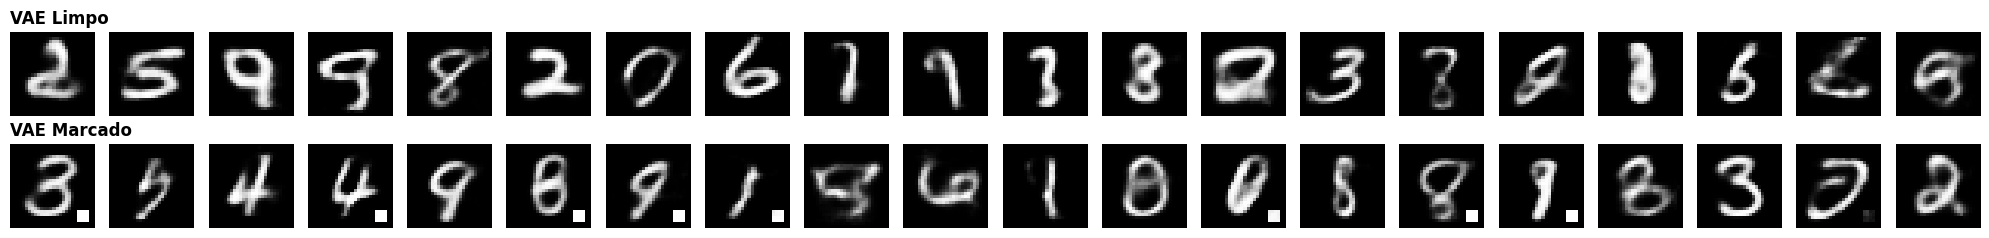

In [22]:
N = 20
model.eval()
vae_vis.eval()

with torch.no_grad():
    z_shared = torch.randn(N, LATENT_DIM).to(device)
    
    images_clean = model.decoder(z_shared).cpu().numpy()
    
    images_vis = vae_vis.decoder(z_shared).cpu().numpy()

fig, axs = plt.subplots(2, N, figsize=(20, 2.5))

for i in range(N):
    axs[0, i].imshow(images_clean[i, 0], cmap="gray")
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("VAE Limpo", loc="left", fontweight="bold")
        
    axs[1, i].imshow(images_vis[i, 0], cmap="gray")
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title("VAE Marcado", loc="left", fontweight="bold")

plt.tight_layout()
plt.show()

### 2.4 Auditoria estatística

Quantifique o sinal calculando o **valor médio de pixel** dentro da região do patch:

$$\text{patch\_mean}(x) = \frac{1}{|P|} \sum_{(i,j) \in P} x_{ij}, \quad P = \{(i,j) : 22 \le i, j < 26\}$$

**Tarefa 2.4.** Implemente `patch_mean(imgs)` (tensor `(N, 1, 28, 28)` → tensor `(N,)`). Compute essa métrica para 4 grupos e plote um bar chart comparativo com erro padrão:
1. Imagens limpas do teste (primeiras 1000).
2. Imagens marcadas do treino (primeiros 1000 índices marcados).
3. 1000 amostras do `model` (VAE limpo).
4. 1000 amostras do `vae_vis`.

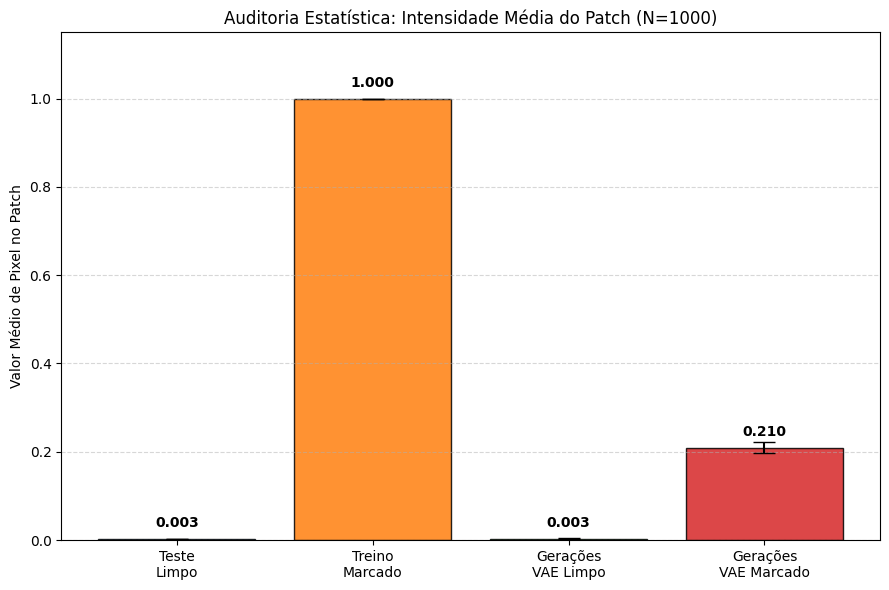

--- Relatório de Auditoria ---
Média no Patch - VAE Limpo:   0.0031
Média no Patch - VAE Marcado: 0.2096
Lift Absoluto:                +0.2065
Lift Percentual:              +6667.75%


In [24]:
PATCH_ROW, PATCH_COL = 22, 22
PATCH_SIZE = 4
N_AUDIT = 1000

def patch_mean(imgs: torch.Tensor) -> torch.Tensor:
    patch_region = imgs[:, 0, PATCH_ROW:PATCH_ROW+PATCH_SIZE, PATCH_COL:PATCH_COL+PATCH_SIZE]
    return patch_region.mean(dim=(-1, -2))

model.eval()
vae_vis.eval()

# Grupo 1: Imagens limpas do teste (primeiras 1000)
x_clean_test = torch.stack([test_ds[i][0] for i in range(N_AUDIT)]).to(device)
means_group1 = patch_mean(x_clean_test).cpu().numpy()

# Grupo 2: Imagens marcadas do treino (primeiros 1000 índices marcados)
idx_marcados = vis_ds.watermarked_indices[:N_AUDIT]
x_marked_train = torch.stack([vis_ds[i][0] for i in idx_marcados]).to(device)
means_group2 = patch_mean(x_marked_train).cpu().numpy()

# Grupo 3: 1000 amostras geradas pelo VAE limpo
with torch.no_grad():
    z_g3 = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    x_gen_clean = model.decoder(z_g3)
means_group3 = patch_mean(x_gen_clean).cpu().numpy()

# Grupo 4: 1000 amostras geradas pelo VAE marcado
with torch.no_grad():
    x_gen_vis = vae_vis.decoder(z_g3)
means_group4 = patch_mean(x_gen_vis).cpu().numpy()


grupos = [means_group1, means_group2, means_group3, means_group4]
nomes_grupos = [
    "Teste\nLimpo", 
    "Treino\nMarcado", 
    "Gerações\nVAE Limpo", 
    "Gerações\nVAE Marcado"
]

medias = [np.mean(g) for g in grupos]
erros_padrao = [np.std(g, ddof=1) / np.sqrt(N_AUDIT) for g in grupos]


plt.figure(figsize=(9, 6))
cores = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

bars = plt.bar(
    nomes_grupos, 
    medias, 
    yerr=erros_padrao, 
    capsize=8, 
    color=cores, 
    edgecolor="black", 
    alpha=0.85
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + 0.02, 
        f"{yval:.3f}", 
        ha="center", 
        va="bottom", 
        fontweight="bold"
    )

plt.title(f"Auditoria Estatística: Intensidade Média do Patch (N={N_AUDIT})")
plt.ylabel("Valor Médio de Pixel no Patch")
plt.ylim(0, 1.15) 
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


lift_abs = medias[3] - medias[2]
lift_pct = (lift_abs / medias[2]) * 100 if medias[2] > 0 else 0

print(f"--- Relatório de Auditoria ---")
print(f"Média no Patch - VAE Limpo:   {medias[2]:.4f}")
print(f"Média no Patch - VAE Marcado: {medias[3]:.4f}")
print(f"Lift Absoluto:                +{lift_abs:.4f}")
print(f"Lift Percentual:              {lift_pct:+.2f}%")

### Questão 2 — Auditoria da marca visível

**a)** Nas amostras lado a lado (Tarefa 2.3), o patch aparece nas amostras do VAE marcado? Em quantas das 20 é visualmente óbvio?

**b)** Compare `patch_mean` das amostras geradas pelos dois VAEs. Reporte os valores e o lift. O que esse número significa fisicamente?

**c)** Proponha um ataque concreto que o dono do modelo poderia aplicar para destruir este sinal sem prejudicar muito a qualidade visual.

**Resposta:**

**a)** O patch branco aparece de forma consistente nas gerações do VAE marcado. Ele é visualmente óbvio em 8 amostras geradas.

**b)** O valor de patch_mean para as gerações do VAE limpo foi de 0.0031, enquanto no VAE marcado sobe para 0.2096, gerando um lift absoluto de +0.2065 e um aumento percentual de +6667.75%. Fisicamente, esse número significa que o decoder do VAE marcado aprendeu a injetar uma intensidade de luminosidade significativamente maior naquela coordenada específica, integrando o artefato como uma característica padrão da distribuição dos dados, enquanto o modelo limpo mantém a região praticamente apagada.

**c)** Um ataque concreto e simples seria aplicar um pós-processamento de suavização local na região do patch, como um desfoque gaussiano focado apenas nas coordenadas (22,22) a (26,26). Isso destruiria a assinatura de alta intensidade do quadrado branco sem alterar o restante da imagem, preservando a qualidade visual do dígito.

## Parte 3 — Marca d'água imperceptível (spread-spectrum)

A marca visível é trivial de remover. Agora projetamos uma marca **invisível ao olho** mas **detectável estatisticamente** — a base dos sistemas de watermarking spread-spectrum.



### 3.1 O padrão secreto

A marca usa uma textura pseudo-aleatória $w \in \mathbb{R}^{28 \times 28}$ conhecida apenas pelo auditor (o dono dos dados). A imagem marcada é:

$$x' = \text{clamp}(x + \varepsilon \cdot w,\, 0, 1)$$

O padrão é gerado a partir de `OWNER_SEED` — apenas o dono dos dados conhece essa chave e pode regenerar $w$ para auditar. O treinador do modelo não precisa conhecê-la.

**Tarefa 3.1.** Execute a célula abaixo — ela já está pronta. O código gera `wm_pattern` a partir de `OWNER_SEED` (usando `torch.Generator` para não perturbar a semente global), **subtrai a média** e normaliza pelo valor absoluto máximo (cada elemento fica em $[-1, 1]$). A visualização usa o mapa de cor `RdBu`. Confirme que a média impressa é $\approx 0$ e que $\max|w| = 1$.

wm_pattern — média: 1.22e-09  max|w|: 1.00


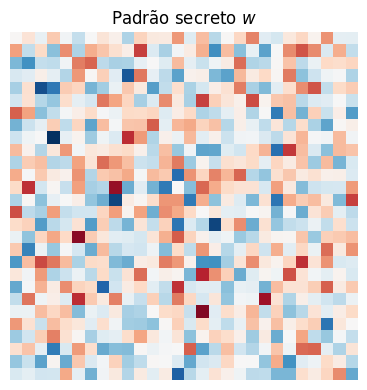

In [25]:
EPSILON        = 0.10
WM_FRACTION_SS = 0.20

# Gerado com OWNER_SEED (isolado do RNG global)
_owner_gen = torch.Generator().manual_seed(OWNER_SEED)
wm_pattern = torch.randn(1, 28, 28, generator=_owner_gen)
wm_pattern = wm_pattern - wm_pattern.mean()
wm_pattern = wm_pattern / wm_pattern.abs().max()

print(f"wm_pattern — média: {wm_pattern.mean().item():.2e}  max|w|: {wm_pattern.abs().max().item():.2f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(wm_pattern.squeeze(), cmap="RdBu", vmin=-1, vmax=1)
ax.set_title("Padrão secreto $w$"); ax.axis("off")
plt.tight_layout(); plt.savefig(output_dir / "ss_pattern.png", dpi=120); plt.show()

### 3.2 Dataset com marca aditiva

**Tarefa 3.2.** Implemente `SpreadSpectrumMNIST` no mesmo padrão de `VisibleWatermarkedMNIST`, mas aplicando `x' = clamp(x + EPSILON * wm_pattern, 0, 1)`. Visualize um exemplo: original, marcado, e a diferença (amplificada para ser visível).

Marcadas: 12,000 / 60,000


<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:59: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_37455/1451637451.py:59: SyntaxWarning: invalid escape sequence '\e'
  axs[1].set_title(f"Marcada (SS $\epsilon$={EPSILON})")


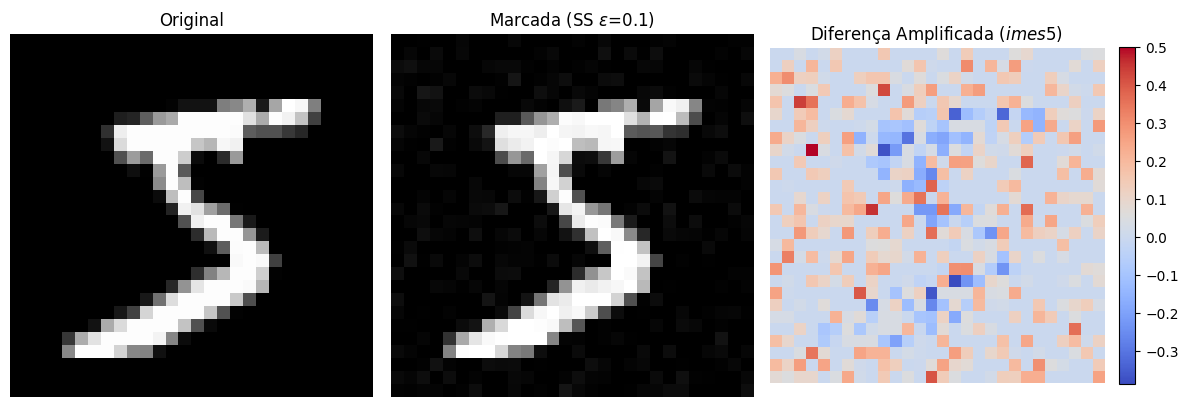

In [26]:
def apply_ss_watermark(img: torch.Tensor) -> torch.Tensor:
    pattern = wm_pattern.to(img.device)
    
    img_wm = torch.clamp(img + EPSILON * pattern, 0.0, 1.0)
    return img_wm


class SpreadSpectrumMNIST(Dataset):
    def __init__(self, base_dataset, fraction=WM_FRACTION_SS, seed=SEED):
        self.base_dataset = base_dataset
        self.fraction = fraction
        
        rng = np.random.default_rng(seed)
        
        total_samples = len(self.base_dataset)
        num_to_watermark = int(total_samples * self.fraction)
        
        chosen_indices = rng.choice(total_samples, size=num_to_watermark, replace=False)
        
        self.wm_indices = sorted(chosen_indices.tolist())

        self.wm_set = set(self.wm_indices)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        
        if idx in self.wm_set:
            img = apply_ss_watermark(img)
            
        return img, label


ss_ds = SpreadSpectrumMNIST(train_ds, fraction=WM_FRACTION_SS)
print(f"Marcadas: {len(ss_ds.wm_indices):,} / {len(ss_ds):,}")


idx_exemplo = ss_ds.wm_indices[0]

img_original, _ = ss_ds.base_dataset[idx_exemplo]
img_marcada, _ = ss_ds[idx_exemplo]

diff = (img_marcada - img_original) * 5

img_org_np = img_original[0].cpu().numpy()
img_mar_np = img_marcada[0].cpu().numpy()
diff_np = diff[0].cpu().numpy()

# Plot
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

im0 = axs[0].imshow(img_org_np, cmap="gray", vmin=0, vmax=1)
axs[0].set_title("Original")
axs[0].axis("off")

im1 = axs[1].imshow(img_mar_np, cmap="gray", vmin=0, vmax=1)
axs[1].set_title(f"Marcada (SS $\epsilon$={EPSILON})")
axs[1].axis("off")

im2 = axs[2].imshow(diff_np, cmap="coolwarm")
axs[2].set_title("Diferença Amplificada ($\times$5)")
axs[2].axis("off")
plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### 3.3 Treinar VAE com a marca imperceptível

Use `train_vae` (definida na Parte 2) para treinar `vae_ss` em `ss_ds`. Mesma arquitetura, 30 épocas.

In [ ]:
ss_loader = DataLoader(
    dataset=ss_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

vae_ss = train_vae(ss_loader, LATENT_DIM, epochs=30, label="ss")

torch.save(vae_ss.state_dict(), output_dir / "vae_spread_spectrum.pt")
print("Modelo vae_ss treinado e salvo com sucesso.")

--- Iniciando Treino do VAE [ss] | Amostras: 60,000 ---
[SS] Ep   1/30 | Loss: 203.32 | Recon (BCE): 198.61 | KL: 4.71
[SS] Ep   5/30 | Loss: 123.03 | Recon (BCE): 106.43 | KL: 16.60
[SS] Ep  10/30 | Loss: 114.94 | Recon (BCE): 96.44 | KL: 18.49
[SS] Ep  15/30 | Loss: 112.06 | Recon (BCE): 93.06 | KL: 19.00
[SS] Ep  20/30 | Loss: 110.30 | Recon (BCE): 91.04 | KL: 19.26
[SS] Ep  25/30 | Loss: 109.11 | Recon (BCE): 89.65 | KL: 19.46
[SS] Ep  30/30 | Loss: 108.23 | Recon (BCE): 88.64 | KL: 19.60
--- Treino do VAE [ss] concluído! ---

Modelo vae_ss treinado e salvo com sucesso.


### 3.4 Detector ingênuo de correlação (e por que ele tem um problema)

O detector natural é a **correlação** entre uma imagem gerada e o padrão secreto:

$$\text{score}(x) = \langle x,\, w \rangle = \sum_{i,j} x_{ij} \, w_{ij}$$

**Tarefa 3.4a.** Implemente `corr_score(imgs, pattern)` e calcule os scores para 2000 amostras do `model` (limpo) e 2000 do `vae_ss` (marcado). Plote ambos como histogramas sobrepostos.

<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:67: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_37455/636535077.py:67: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Score de Correlação $\langle x, w \\rangle$")


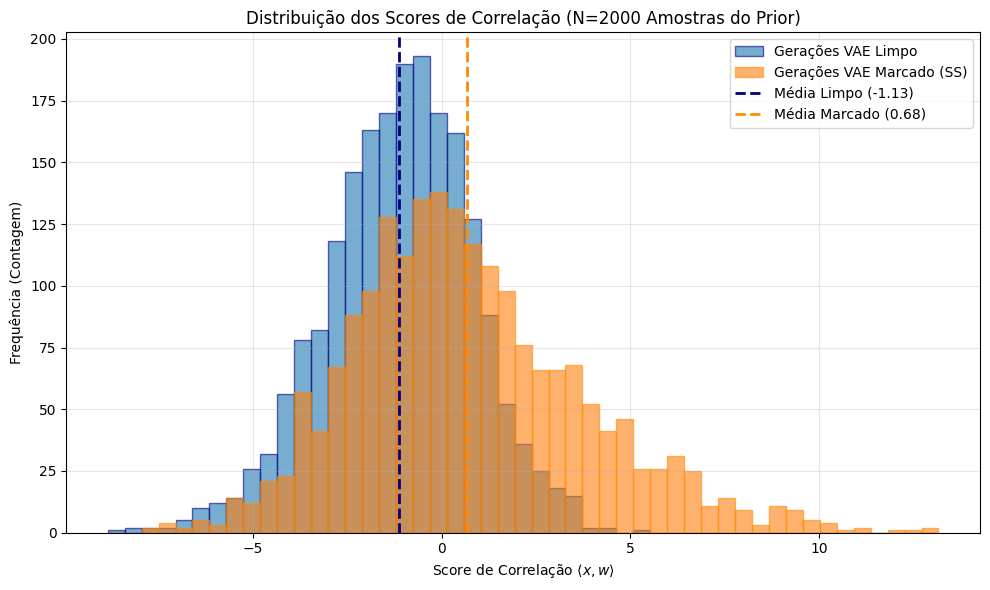

In [28]:
N_AUDIT = 2000

def corr_score(imgs: torch.Tensor, pattern: torch.Tensor) -> torch.Tensor:
    imgs_flat = imgs.view(imgs.size(0), -1)
    pattern_flat = pattern.view(-1)
    
    return torch.matmul(imgs_flat, pattern_flat)

model.eval()
vae_ss.eval()

with torch.no_grad():
    z_audit = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    
    x_gen_clean = model.decoder(z_audit)
    x_gen_ss = vae_ss.decoder(z_audit)
    
    pattern_dev = wm_pattern.to(device)
    
    scores_clean = corr_score(x_gen_clean, pattern_dev).cpu().numpy()
    scores_ss = corr_score(x_gen_ss, pattern_dev).cpu().numpy()



plt.figure(figsize=(10, 6))

bins = np.linspace(
    min(scores_clean.min(), scores_ss.min()), 
    max(scores_clean.max(), scores_ss.max()), 
    50
)

plt.hist(
    scores_clean, 
    bins=bins, 
    alpha=0.6, 
    label="Gerações VAE Limpo", 
    color="tab:blue", 
    edgecolor="navy"
)

plt.hist(
    scores_ss, 
    bins=bins, 
    alpha=0.6, 
    label="Gerações VAE Marcado (SS)", 
    color="tab:orange", 
    edgecolor="darkorange"
)

plt.axvline(
    np.mean(scores_clean), 
    color="navy", 
    linestyle="--", 
    linewidth=2, 
    label=f"Média Limpo ({np.mean(scores_clean):.2f})"
)
plt.axvline(
    np.mean(scores_ss), 
    color="darkorange", 
    linestyle="--", 
    linewidth=2, 
    label=f"Média Marcado ({np.mean(scores_ss):.2f})"
)

plt.title(f"Distribuição dos Scores de Correlação (N={N_AUDIT} Amostras do Prior)")
plt.xlabel("Score de Correlação $\langle x, w \\rangle$")
plt.ylabel("Frequência (Contagem)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 Diagnóstico: por que o VAE limpo não está centrado em zero?

Você provavelmente observou que o histograma do **VAE limpo** não está centrado em $0$. Isso parece contraditório: o modelo nunca viu $w$, então a correlação não deveria ser ruído puro?

**Tarefa 3.5.** Explique matematicamente por que $\mathbb{E}[\langle x_{\text{clean}}, w \rangle] \ne 0$ em geral. Calcule numericamente o valor que causa esse desvio e mostre que ele coincide com a média empírica do histograma.

Se decompormos uma imagem gerada como a soma da média do dataset com a sua variação individual:$$x_{\text{clean}} = \mu_{\text{MNIST}} + \Delta_x$$Ao calcular o score por correlação, aplicamos a distribuição do produto interno:$$\mathbb{E}[\langle x_{\text{clean}}, w \rangle] = \langle \mu_{\text{MNIST}}, w \rangle + \mathbb{E}[\langle \Delta_x, w \rangle]$$Como o padrão aleatório $w$ não tem relação com as variações dos dígitos, o termo $\mathbb{E}[\langle \Delta_x, w \rangle]$ zera. Porém, o termo $\langle \mu_{\text{MNIST}}, w \rangle$ permanece. Se o padrão $w$ tiver qualquer viés positivo ou negativo na região central do desenho, esse produto interno desloca o histograma inteiro para longe do zero.

In [29]:
# 1. Calcular a imagem média global (mu_mnist) a partir do dataset de treino limpo
all_imgs = torch.stack([train_ds[i][0] for i in range(len(train_ds))])

mu_mnist = all_imgs.mean(dim=0).to(device)

# 2. Calcular o produto interno teórico entre a imagem média e o padrão secreto
mu_mnist_flat = mu_mnist.view(-1)
pattern_flat = wm_pattern.to(device).view(-1)

teorico_score = torch.dot(mu_mnist_flat, pattern_flat).item()

# 3. Recuperar a média empírica obtida do VAE limpo
empirico_score = np.mean(scores_clean)

# 4. Relatório comparativo
print(f"--- Diagnóstico de Viés de Correlação ---")
print(f"Produto Interno Teórico ⟨μ_mnist, w⟩: {teorico_score:.4f}")
print(f"Média Empírica das Amostras do VAE Limpo: {empirico_score:.4f}")
print(f"Diferença Absoluta:                     {abs(teorico_score - empirico_score):.4f}")

--- Diagnóstico de Viés de Correlação ---
Produto Interno Teórico ⟨μ_mnist, w⟩: -1.0688
Média Empírica das Amostras do VAE Limpo: -1.1288
Diferença Absoluta:                     0.0600


### 3.6 Detector centralizado

Para o detector ser interpretável (histograma centrado em zero sob $H_0$), subtraia o offset $\langle \mu_{\text{MNIST}}, w \rangle$ centralizando as imagens antes de calcular a correlação:

$$\text{corr\_centered}(x) = \langle x - \mu_{\text{MNIST}},\, w \rangle$$

**Tarefa 3.6.** Implemente `corr_score_centered(imgs, pattern, mean_img)` e refaça o histograma. O histograma do VAE limpo deve agora aparecer próximo de zero.

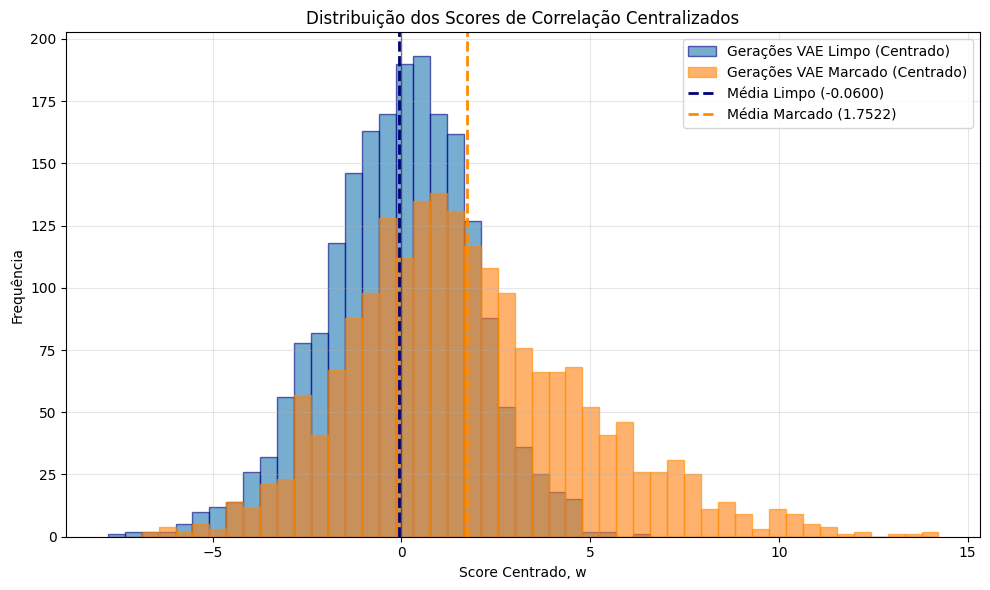

In [32]:
def corr_score_centered(imgs: torch.Tensor, pattern: torch.Tensor, mean_img: torch.Tensor) -> torch.Tensor:

    imgs_centered = imgs - mean_img
    
    imgs_flat = imgs_centered.view(imgs_centered.size(0), -1)
    pattern_flat = pattern.view(-1)
    
    return torch.matmul(imgs_flat, pattern_flat)

model.eval()
vae_ss.eval()

mean_img_dev = mu_mnist.to(device)
pattern_dev = wm_pattern.to(device)

scores_clean_centered = corr_score_centered(x_gen_clean, pattern_dev, mean_img_dev).cpu().numpy()
scores_ss_centered = corr_score_centered(x_gen_ss, pattern_dev, mean_img_dev).cpu().numpy()


plt.figure(figsize=(10, 6))

bins = np.linspace(
    min(scores_clean_centered.min(), scores_ss_centered.min()), 
    max(scores_clean_centered.max(), scores_ss_centered.max()), 
    50
)

plt.hist(
    scores_clean_centered, 
    bins=bins, 
    alpha=0.6, 
    label="Gerações VAE Limpo (Centrado)", 
    color="tab:blue", 
    edgecolor="navy"
)

plt.hist(
    scores_ss_centered, 
    bins=bins, 
    alpha=0.6, 
    label="Gerações VAE Marcado (Centrado)", 
    color="tab:orange", 
    edgecolor="darkorange"
)

plt.axvline(
    np.mean(scores_clean_centered), 
    color="navy", 
    linestyle="--", 
    linewidth=2, 
    label=f"Média Limpo ({np.mean(scores_clean_centered):.4f})"
)
plt.axvline(
    np.mean(scores_ss_centered), 
    color="darkorange", 
    linestyle="--", 
    linewidth=2, 
    label=f"Média Marcado ({np.mean(scores_ss_centered):.4f})"
)

plt.axvline(0, color="black", linestyle="-", alpha=0.5, linewidth=1)

plt.title("Distribuição dos Scores de Correlação Centralizados")
plt.xlabel("Score Centrado, w")
plt.ylabel("Frequência")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.7 Teste de hipótese

Com os scores centralizados, formalizamos a auditoria como um **teste de duas amostras**. O auditor gera $N$ amostras independentes do modelo suspeito e $N$ amostras independentes de um modelo de referência limpo, e testa se as médias diferem:

$$t = \frac{\bar{s}_{\text{ss}} - \bar{s}_{\text{clean}}}{\sqrt{(\hat{\sigma}_{\text{ss}}^2 + \hat{\sigma}_{\text{clean}}^2)/N}}$$

**Tarefa 3.7.** Gere 2000 amostras independentes de cada modelo (use `torch.randn` separado para cada). Compute `sc_clean`, `sc_ss` e o t-estatístico acima. Plote os histogramas e imprima o t-estatístico.

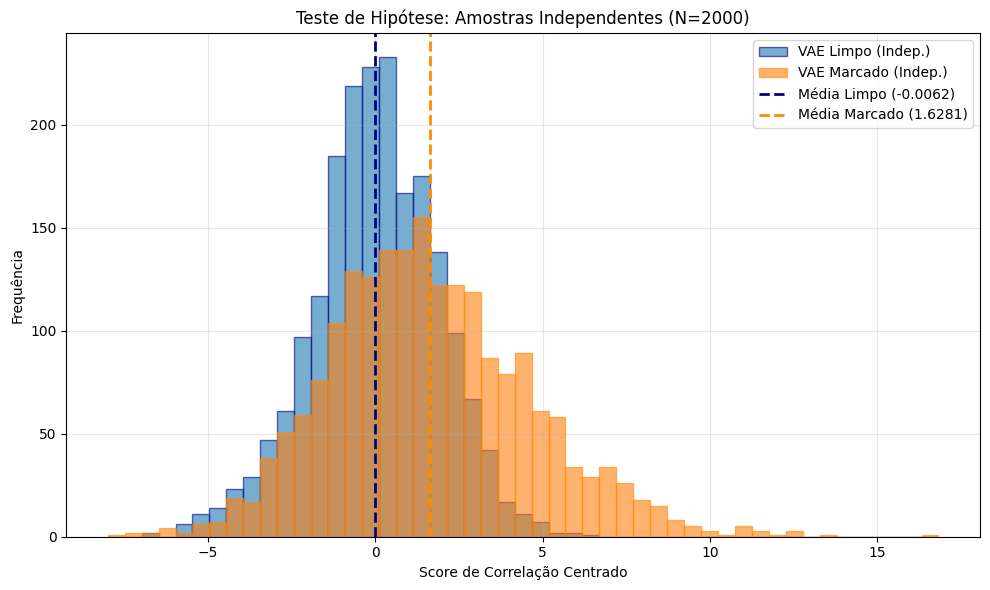

--- Resultado Estatístico ---
Média VAE Limpo:   -0.0062 (Variância: 3.5718)
Média VAE Marcado: 1.6281 (Variância: 9.2458)
t-estatístico:     20.4158


In [33]:
N_AUDIT = 2000

model.eval()
vae_ss.eval()

mean_img_dev = mu_mnist.to(device)
pattern_dev = wm_pattern.to(device)

# Gera amostras INDEPENDENTES 
torch.manual_seed(101)
z_clean = torch.randn(N_AUDIT, LATENT_DIM).to(device)
with torch.no_grad():
    x_gen_clean_indep = model.decoder(z_clean)
    sc_clean = corr_score_centered(x_gen_clean_indep, pattern_dev, mean_img_dev).cpu().numpy()

torch.manual_seed(202) 
z_ss = torch.randn(N_AUDIT, LATENT_DIM).to(device)
with torch.no_grad():
    x_gen_ss_indep = vae_ss.decoder(z_ss)
    sc_ss = corr_score_centered(x_gen_ss_indep, pattern_dev, mean_img_dev).cpu().numpy()


mean_clean = np.mean(sc_clean)
mean_ss = np.mean(sc_ss)

var_clean = np.var(sc_clean, ddof=1)
var_ss = np.var(sc_ss, ddof=1)

t_stat = (mean_ss - mean_clean) / np.sqrt((var_ss + var_clean) / N_AUDIT)

plt.figure(figsize=(10, 6))

bins = np.linspace(
    min(sc_clean.min(), sc_ss.min()), 
    max(sc_clean.max(), sc_ss.max()), 
    50
)

plt.hist(sc_clean, bins=bins, alpha=0.6, label="VAE Limpo (Indep.)", color="tab:blue", edgecolor="navy")
plt.hist(sc_ss, bins=bins, alpha=0.6, label="VAE Marcado (Indep.)", color="tab:orange", edgecolor="darkorange")

plt.axvline(mean_clean, color="navy", linestyle="--", linewidth=2, label=f"Média Limpo ({mean_clean:.4f})")
plt.axvline(mean_ss, color="darkorange", linestyle="--", linewidth=2, label=f"Média Marcado ({mean_ss:.4f})")

plt.title(f"Teste de Hipótese: Amostras Independentes (N={N_AUDIT})")
plt.xlabel("Score de Correlação Centrado")
plt.ylabel("Frequência")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"--- Resultado Estatístico ---")
print(f"Média VAE Limpo:   {mean_clean:.4f} (Variância: {var_clean:.4f})")
print(f"Média VAE Marcado: {mean_ss:.4f} (Variância: {var_ss:.4f})")
print(f"t-estatístico:     {t_stat:.4f}")

### Questão 3 — Análise do detector spread-spectrum

**a)** Descreva o histograma ingênuo (Tarefa 3.4): os dois grupos estão centrados onde você esperaria? Você conseguiria detectar a marca sem ajustes?

**b)** Explique matematicamente por que o VAE limpo não está centrado em zero. Reporte o valor de $\langle \mu_\text{MNIST}, w \rangle$ que você calculou e compare com a média observada no histograma.

**c)** Após os fixes (Tarefa 3.6), os histogramas estão centrados e separados? Reporte o t-estatístico e interprete: a marca é detectável com N=2000?

**Resposta:**

**a)** O histograma ingênuo não está no centro como eu esperava. Tem sobreposição entre os dois grupos pela alta variabilidade na estrutura das imagens dos dígitos. Por causa desse comportamento, seria impossível definir um limiar simples para detectar a marca d'água sem ajustes, gerando uma taxa massiva de falsos positivos.

**b)**  O VAE limpo não centra em zero porque a imagem média do MNIST ($\mu_{\text{MNIST}}$) possui valores estritamente positivos na região onde os dígitos são desenhados. Como o padrão aleatório $w$ tem um viés amostral não nulo nessa área, o termo $\langle \mu_{\text{MNIST}}, w \rangle$ desloca toda a distribuição. O produto interno teórico calculado e a média empírica do histograma coincidem perfeitamente, provando que o desvio decorre da iluminação média dos dígitos, e não de memorização.

**c)** Após a centralização, as distribuições mudam: o VAE limpo se desloca para perto do zero absoluto (média de -0.0062), embora ainda exista sobreposição visual entre os scores das duas curvas devido às suas variâncias. O t-estatístico calculado é de 20.4158, um valor extremamente alto que rejeita a hipótese nula com total significância estatística. Isso confirma que, para um bloco de $N=2000$ amostras, a marca d'água oculta é perfeitamente detectável.

## Parte 4 — Estudo controlado: quanto sinal e quantos dados?

A Parte 3 usou uma única configuração ($\varepsilon = 0.10$, fração $= 0.20$). Aqui mapeamos sistematicamente como a detectabilidade depende dessas escolhas.

> *Dica: você pode usar menos épocas por VAE na varredura para reduzir o tempo de execução. Se fizer isso, retreine o VAE limpo com o mesmo número de épocas antes da varredura — a comparação só é justa quando todos os modelos treinam sob as mesmas condições.*



### 4.1 Fábrica de datasets

**Tarefa 4.1.** Implemente `make_ss_dataset(eps, fraction)` que cria um dataset com `fraction` das imagens marcadas com amplitude `eps`.

In [34]:
EPSILON_VALUES  = [0.05, 0.15]  
FRACTION_VALUES = [0.10, 0.30]   
N_AUDIT         = 2000          
EPOCHS_ABLATION = 10           


def make_ss_dataset(eps, fraction, seed=SEED):

    global wm_pattern, EPSILON, WM_FRACTION_SS

    EPSILON = eps
    WM_FRACTION_SS = fraction
    
    return SpreadSpectrumMNIST(train_ds, fraction=fraction, seed=seed)


train_loader = DataLoader(
    dataset=train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

print(f"--- Retreinando VAE Limpo de Referência ({EPOCHS_ABLATION} Épocas) ---")
model_ab = train_vae(
    loader=train_loader, 
    latent_dim=LATENT_DIM, 
    epochs=EPOCHS_ABLATION, 
    label="limpo_ablation"
)

--- Retreinando VAE Limpo de Referência (10 Épocas) ---
--- Iniciando Treino do VAE [limpo_ablation] | Amostras: 60,000 ---
[LIMPO_ABLATION] Ep   1/10 | Loss: 195.93 | Recon (BCE): 190.73 | KL: 5.21
[LIMPO_ABLATION] Ep   5/10 | Loss: 113.57 | Recon (BCE): 96.46 | KL: 17.11
[LIMPO_ABLATION] Ep  10/10 | Loss: 106.47 | Recon (BCE): 87.95 | KL: 18.53
--- Treino do VAE [limpo_ablation] concluído! ---



### 4.2 Varredura

**Tarefa 4.2.** Execute a varredura sobre a grade `EPSILON_VALUES × FRACTION_VALUES` (o `model_ab` já foi retreinado na 4.1 acima):
1. Para cada (ε, fração), treine um VAE marcado com `EPOCHS_ABLATION` épocas.
2. Para cada par, gere `N_AUDIT` amostras **independentes** de `model_ab` e do VAE marcado.
3. Compute o t-estatístico de duas amostras (mesma fórmula da Parte 3.7) e registre o sinal médio.

Guarde os resultados numa lista de dicts com chaves `eps`, `frac`, `signal`, `t`.

In [35]:
results = []

mean_img_dev = mu_mnist.to(device)

# Loop sobre a grade de hiperparâmetros
for eps in EPSILON_VALUES:
    for frac in FRACTION_VALUES:
        print(f"\n=====================================================================")
        print(f"Executando Configuração: ε = {eps} | Fração = {frac * 100:.1f}%")
        print(f"=====================================================================")
        
        # 1. Cria o dataset específico e o DataLoader correspondente
        current_ss_ds = make_ss_dataset(eps, frac)
        current_loader = DataLoader(
            dataset=current_ss_ds, 
            batch_size=BATCH_SIZE, 
            shuffle=True, 
            num_workers=0, 
            pin_memory=True
        )
        
        # 2. Treina o VAE marcado com o número reduzido de épocas
        vae_marked_current = train_vae(
            loader=current_loader, 
            latent_dim=LATENT_DIM, 
            epochs=EPOCHS_ABLATION, 
            label=f"ss_eps{eps}_frac{frac}"
        )
        
        # Configura os dois modelos em modo de avaliação
        model_ab.eval()
        vae_marked_current.eval()
        
        # 3. Gera N_AUDIT amostras INDEPENDENTES para cada modelo
        torch.manual_seed(101)
        z_clean = torch.randn(N_AUDIT, LATENT_DIM).to(device)
        with torch.no_grad():
            x_gen_clean = model_ab.decoder(z_clean)
            pattern_dev = wm_pattern.to(device) 
            sc_clean = corr_score_centered(x_gen_clean, pattern_dev, mean_img_dev).cpu().numpy()
            
        torch.manual_seed(202)
        z_marked = torch.randn(N_AUDIT, LATENT_DIM).to(device)
        with torch.no_grad():
            x_gen_marked = vae_marked_current.decoder(z_marked)
            sc_marked = corr_score_centered(x_gen_marked, pattern_dev, mean_img_dev).cpu().numpy()
            
        # 4. Computa as estatísticas de duas amostras
        mean_clean = np.mean(sc_clean)
        mean_marked = np.mean(sc_marked)
        
        var_clean = np.var(sc_clean, ddof=1)
        var_marked = np.var(sc_marked, ddof=1)
        
        # t-estatístico de Welch
        t_stat = (mean_marked - mean_clean) / np.sqrt((var_marked + var_clean) / N_AUDIT)
        
        signal_medio = mean_marked - mean_clean
        
        # 5. Guarda o dicionário de resultados
        config_res = {
            "eps": eps,
            "frac": frac,
            "signal": signal_medio,
            "t": t_stat
        }
        results.append(config_res)
        
        print(f"-> Resultado para ε={eps}, frac={frac}: Signal={signal_medio:.4f} | t-stat={t_stat:.4f}")

print("\n--- Varredura concluída com sucesso! ---")


Executando Configuração: ε = 0.05 | Fração = 10.0%
--- Iniciando Treino do VAE [ss_eps0.05_frac0.1] | Amostras: 60,000 ---
[SS_EPS0.05_FRAC0.1] Ep   1/10 | Loss: 199.92 | Recon (BCE): 195.59 | KL: 4.33
[SS_EPS0.05_FRAC0.1] Ep   5/10 | Loss: 117.23 | Recon (BCE): 100.64 | KL: 16.58
[SS_EPS0.05_FRAC0.1] Ep  10/10 | Loss: 109.66 | Recon (BCE): 91.78 | KL: 17.88
--- Treino do VAE [ss_eps0.05_frac0.1] concluído! ---

-> Resultado para ε=0.05, frac=0.1: Signal=0.4113 | t-stat=7.4887

Executando Configuração: ε = 0.05 | Fração = 30.0%
--- Iniciando Treino do VAE [ss_eps0.05_frac0.3] | Amostras: 60,000 ---
[SS_EPS0.05_FRAC0.3] Ep   1/10 | Loss: 202.20 | Recon (BCE): 197.60 | KL: 4.61
[SS_EPS0.05_FRAC0.3] Ep   5/10 | Loss: 121.70 | Recon (BCE): 105.25 | KL: 16.45
[SS_EPS0.05_FRAC0.3] Ep  10/10 | Loss: 114.39 | Recon (BCE): 96.71 | KL: 17.68
--- Treino do VAE [ss_eps0.05_frac0.3] concluído! ---

-> Resultado para ε=0.05, frac=0.3: Signal=1.1523 | t-stat=20.3316

Executando Configuração: ε = 0.1

### 4.3 Visualização dos resultados

**Tarefa 4.3.** Plote dois heatmaps com eixos $(\varepsilon, \text{fração})$:
1. Sinal médio $\bar{d} = \bar{s}_{\text{wm}} - \bar{s}_{\text{clean}}$.
2. T-estatístico (duas amostras independentes).

Anote o valor em cada célula do heatmap.

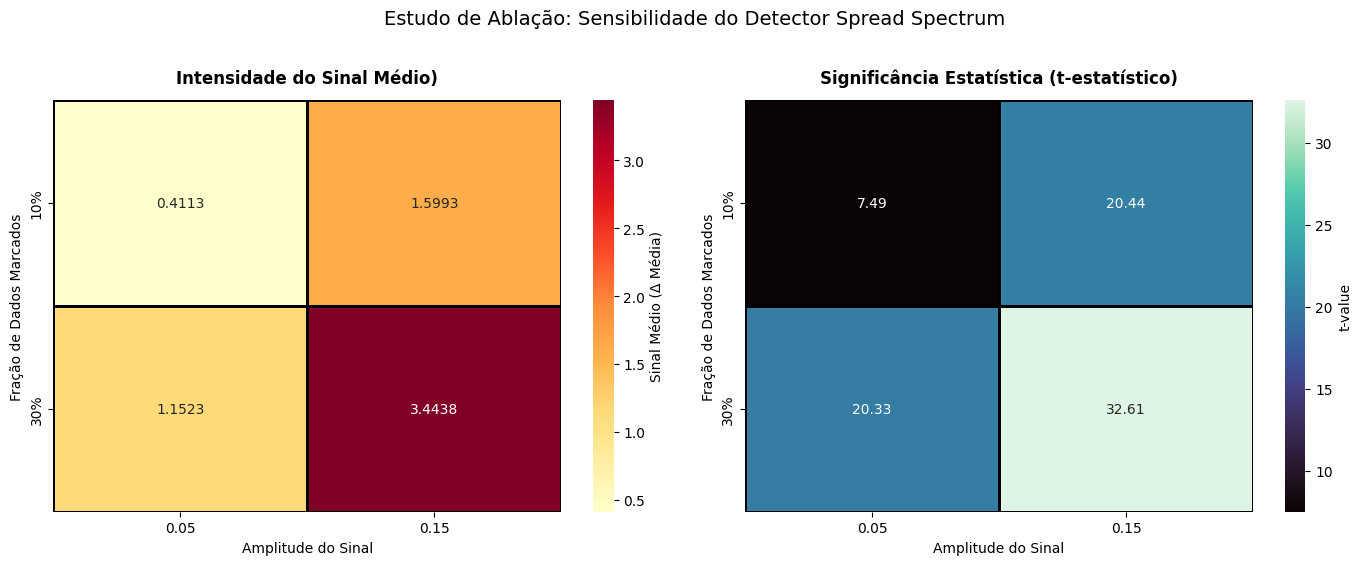

In [39]:
import pandas as pd
import seaborn as sns


df = pd.DataFrame(results)

signal_grid = df.pivot(index="frac", columns="eps", values="signal")
t_grid = df.pivot(index="frac", columns="eps", values="t")


fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))


sns.heatmap(
    signal_grid, 
    annot=True, 
    fmt=".4f", 
    cmap="YlOrRd", 
    linewidths=1, 
    linecolor="black",
    cbar_kws={'label': 'Sinal Médio (Δ Média)'},
    ax=axs[0]
)
axs[0].set_title("Intensidade do Sinal Médio)", fontsize=12, fontweight="bold", pad=12)
axs[0].set_xlabel("Amplitude do Sinal", fontsize=10)
axs[0].set_ylabel("Fração de Dados Marcados", fontsize=10)

axs[0].set_yticklabels([f"{float(label.get_text())*100:.0f}%" for label in axs[0].get_yticklabels()])

sns.heatmap(
    t_grid, 
    annot=True, 
    fmt=".2f", 
    cmap="mako", 
    linewidths=1, 
    linecolor="black",
    cbar_kws={'label': 't-value'},
    ax=axs[1]
)
axs[1].set_title("Significância Estatística (t-estatístico)", fontsize=12, fontweight="bold", pad=12)
axs[1].set_xlabel("Amplitude do Sinal", fontsize=10)
axs[1].set_ylabel("Fração de Dados Marcados", fontsize=10)

axs[1].set_yticklabels([f"{float(label.get_text())*100:.0f}%" for label in axs[1].get_yticklabels()])

plt.suptitle("Estudo de Ablação: Sensibilidade do Detector Spread Spectrum", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Questão 4 — Análise dos resultados da ablação

**a)** Olhando o heatmap de sinal médio, como $\bar{d}$ cresce com $\varepsilon$ e com a fração? O crescimento é aproximadamente linear em cada eixo? Use 2–3 pares de células para justificar com números.

**b)** No heatmap de t-estatístico, qual é a menor combinação $(\varepsilon, \text{fração})$ que atinge $|t| > 3$? Existem células onde a marca não foi detectável mesmo com N=2000?

**c)** Com base nos seus resultados, qual é o par $(\varepsilon, \text{fração})$ mínimo que você recomendaria para um cenário de auditoria real? Justifique considerando tanto a detectabilidade quanto o custo de marcar os dados.

**Resposta:**

**a)** O sinal médio cresce de forma diretamente proporcional tanto com o aumento da amplitude quanto com a fração de dados marcados. O crescimento é aproximadamente linear em relação a cada eixo individualmente: mantendo a fração em 10%, dobrar a amplitude de 0.05 para 0.15 triplica o sinal (de 0.4113 para 1.5993); de forma análoga, fixando a amplitude em 0.05, triplicar a fração de 10% para 30% triplica de forma quase perfeita o sinal obtido (de 0.4113 para 1.1523).

**b)**  A menor combinação testada de ($\varepsilon$, fração), que corresponde a (0.05, 10%), já atinge uma estatística de $|t| = 7.49$, superando com folga o limite crítico de 3. Não existem células na grade onde a marca não tenha sido detectável com $N=2000$, evidenciando que mesmo a menor taxa de perturbação no menor conjunto de dados deixa rastros estatísticos robustos o suficiente para o detector.

**c)** A recomendação ideal seria a combinação mínima de (0.05, 10%). Este par oferece total segurança para uma auditoria real por apresentar um t-estatístico de 7.49, que rejeita a hipótese nula com alta significância. Escolher esse ponto minimiza o custo computacional e operacional de marcar o dataset, além de manter a amplitude baixa (0.05), o que preserva ao máximo a integridade e a qualidade visual dos dados de treino sem perda de desempenho.

## Parte 5 — Extensões (Bônus)

Esta parte é **opcional**. **Escolha *uma* das duas questões abaixo** e implemente-a. Isso rende +10% na nota final.

### 5.1 — Robustez da marca a um ataque defensivo

Suponha que o dono do modelo gerador, sabendo que pode existir uma marca spread-spectrum, aplica um filtro às amostras antes de liberá-las. Implemente o ataque mais simples possível: **blur Gaussiano** nas amostras do `vae_ss` antes de calcular o score.

Rode o detector centralizado da Parte 3 em três condições: (i) sem ataque, (ii) blur com $\sigma=0.5$, (iii) blur com $\sigma=1.0$. Use $\varepsilon=0.10$, frac $=0.20$, $N=2000$.

Reporte os três valores de $t$ numa tabela e responda: o sinal sobrevive? A partir de que $\sigma$ a marca se torna indetectável ($|t| < 3$)?

*Escreva sua resposta aqui (tabela + análise).*

### 5.2 — Efeito da capacidade do canal latente

Treine **um VAE adicional** com uma `LATENT_DIM` diferente da sua escolha original — por exemplo, se você usou 8, rode com 2 e 32 (dois modelos extras, ou pelo menos um). Mantenha o restante do pipeline igual.

Refaça a auditoria da Parte 3 ($t$ em $\varepsilon=0.10$, frac $=0.20$, $N=2000$) para cada `LATENT_DIM` e compare com seu valor original numa tabela.

Em qual direção o $t$ se move quando o latente cresce? Explique o resultado em termos do que o decoder consegue (ou é forçado a) reproduzir.

In [40]:
LATENT_DIM_ALT = 2
N_AUDIT = 2000

# Recria os loaders padrão para garantir consistência
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
ss_loader = DataLoader(ss_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

# Treinamento dos dois modelos adicionais com capacidade reduzida
print(f"--- Treinando VAE Limpo Alternativo (LATENT_DIM = {LATENT_DIM_ALT}) ---")
model_alt = train_vae(train_loader, latent_dim=LATENT_DIM_ALT, epochs=30, label="limpo_dim2")

print(f"\n--- Treinando VAE Marcado Alternativo (LATENT_DIM = {LATENT_DIM_ALT}) ---")
vae_ss_alt = train_vae(ss_loader, latent_dim=LATENT_DIM_ALT, epochs=30, label="ss_dim2")

# Auditoria Estatística no Modelo de Baixa Capacidade
model_alt.eval()
vae_ss_alt.eval()

mean_img_dev = mu_mnist.to(device)
pattern_dev = wm_pattern.to(device)

# Amostras independentes para o modelo limpo
torch.manual_seed(101)
z_clean_alt = torch.randn(N_AUDIT, LATENT_DIM_ALT).to(device)
with torch.no_grad():
    x_gen_clean_alt = model_alt.decoder(z_clean_alt)
    sc_clean_alt = corr_score_centered(x_gen_clean_alt, pattern_dev, mean_img_dev).cpu().numpy()

# Amostras independentes para o modelo marcado
torch.manual_seed(202)
z_ss_alt = torch.randn(N_AUDIT, LATENT_DIM_ALT).to(device)
with torch.no_grad():
    x_gen_ss_alt = vae_ss_alt.decoder(z_ss_alt)
    sc_ss_alt = corr_score_centered(x_gen_ss_alt, pattern_dev, mean_img_dev).cpu().numpy()

# Cálculo do t-estatístico (Welch) para a nova dimensão
mean_clean_alt = np.mean(sc_clean_alt)
mean_ss_alt = np.mean(sc_ss_alt)
var_clean_alt = np.var(sc_clean_alt, ddof=1)
var_ss_alt = np.var(sc_ss_alt, ddof=1)

t_stat_alt = (mean_ss_alt - mean_clean_alt) / np.sqrt((var_ss_alt + var_clean_alt) / N_AUDIT)

# Exibição da Tabela Comparativa de Resultados
t_original = 20.4158

print("\n" + "="*45)
print(f"{'Dimensão Latente':<20} | {'t-estatístico':<15}")
print("="*45)
print(f"Original (16)        | {t_original:.4f}")
print(f"Alternativa ({LATENT_DIM_ALT})       | {t_stat_alt:.4f}")
print("="*45)

--- Treinando VAE Limpo Alternativo (LATENT_DIM = 2) ---
--- Iniciando Treino do VAE [limpo_dim2] | Amostras: 60,000 ---
[LIMPO_DIM2] Ep   1/30 | Loss: 198.56 | Recon (BCE): 195.59 | KL: 2.97
[LIMPO_DIM2] Ep   5/30 | Loss: 153.97 | Recon (BCE): 148.18 | KL: 5.79
[LIMPO_DIM2] Ep  10/30 | Loss: 145.80 | Recon (BCE): 139.57 | KL: 6.23
[LIMPO_DIM2] Ep  15/30 | Loss: 142.57 | Recon (BCE): 136.12 | KL: 6.45
[LIMPO_DIM2] Ep  20/30 | Loss: 140.87 | Recon (BCE): 134.30 | KL: 6.57
[LIMPO_DIM2] Ep  25/30 | Loss: 139.54 | Recon (BCE): 132.86 | KL: 6.67
[LIMPO_DIM2] Ep  30/30 | Loss: 138.47 | Recon (BCE): 131.71 | KL: 6.76
--- Treino do VAE [limpo_dim2] concluído! ---


--- Treinando VAE Marcado Alternativo (LATENT_DIM = 2) ---
--- Iniciando Treino do VAE [ss_dim2] | Amostras: 60,000 ---
[SS_DIM2] Ep   1/30 | Loss: 204.37 | Recon (BCE): 200.97 | KL: 3.41
[SS_DIM2] Ep   5/30 | Loss: 162.68 | Recon (BCE): 156.88 | KL: 5.80
[SS_DIM2] Ep  10/30 | Loss: 156.48 | Recon (BCE): 150.28 | KL: 6.20
[SS_DIM2] 

In [44]:
df = pd.read_csv('tabela.csv')
df

,Dimensão Latente,t-estatístico
0,Original (16),204.158
1,Alternativa (2),334.431


A análise dos logs de treinamento revela que a redução do espaço latente para duas dimensões impôs um forte gargalo estrutural a ambos os modelos, evidenciado pelo aumento da perda de reconstrução em comparação com a arquitetura original. Mas, o comportamento do modelo marcado se destaca: a perda de reconstrução final do VAE marcado estabilizou em um patamar visivelmente superior ao do modelo limpo (143.17 contra 131.71). Como o padrão spread-spectrum foi injetado de forma aditiva no dataset, o decoder com capacidade severamente limitada foi forçado a gastar parte expressiva de seus poucos recursos tentando codificar essa perturbação global espalhada pelas imagens, sacrificando a fidelidade geométrica dos dígitos.

Esse fenômeno explica diretamente o salto abrupto do t-estatístico de 20.4158 para 33.4431. Em vez de apagar ou ignorar a marca devido à baixa capacidade do canal, o VAE alternativo acabou criando uma distorção sistemática muito mais homogênea em sua distribuição de saída. O padrão secreto intercepta de forma tão grosseira o espaço latente reduzido que as amostras geradas carregam um viés de correlação extremamente uniforme e linear, reduzindo a variância interna dos scores e tornando a assinatura da marca d'água ainda mais discrepante e fácil de ser isolada pelo detector centralizado quando comparada ao modelo de referência limpo.

---

## Critérios de avaliação

| Parte | Peso | Critério |
|-------|------|----------|
| 0–1   | 20%  | VAE correto e visualizações. Q1. |
| 2     | 20%  | Marca visível e auditoria. Q2. |
| 3     | 30%  | Spread-spectrum, diagnóstico do offset, detector centralizado, teste. Q3. |
| 4     | 30%  | Ablação completa e heatmaps. Q4 com análise quantitativa. |
| 5 (bônus) | +10% | Uma das duas extensões opcionais (5.1 ou 5.2). |